In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.evaluation import evaluate
from src.features import cycle
from src.models.catboost import search_params_recursive_multi_series
from src.visualization import plot_forecast_with_train, plot_forecast
from skforecast.recursive import ForecasterRecursiveMultiSeries
from sklearn.metrics import root_mean_squared_error
import joblib
from catboost import CatBoostRegressor
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def fit_best_model(df_train, best_params, target_cols, exog_cols):
    catboost_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bootstrap_type': 'Bernoulli',
        'subsample': best_params['subsample'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'min_data_in_leaf': best_params['min_data_in_leaf'],
        'random_strength': best_params['random_strength'],
        'random_state': 42,
        'verbose': False,
        'thread_count': -1
    }
    
    lags = best_params['lags']
    
    forecaster = ForecasterRecursiveMultiSeries(
        estimator=CatBoostRegressor(**catboost_params),
        lags=lags
    )

    y_train_dict = {col: df_train[col] for col in target_cols}
    forecaster.fit(series=y_train_dict, exog=df_train[exog_cols])

    return forecaster

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [6]:
model_path = f'../catboost/models/catboost_v3'
target_cols = ['48-1 (0)', '48-1 (3)', '48-1 (5)', '48-1 (7)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [30]:
study = search_params_recursive_multi_series(df_train, df_val, target_cols, exog_cols, max_lags=10, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-17 19:38:02,990] A new study created in memory with name: no-name-230955c8-a0f4-434a-a25b-9ff1683edfbc
[I 2026-05-17 19:38:06,578] Trial 0 finished with value: 0.5099809945710891 and parameters: {'iterations': 1649, 'learning_rate': 0.004268114121006216, 'depth': 5, 'l2_leaf_reg': 0.0010087839463413315, 'subsample': 0.43621482685366386, 'colsample_bylevel': 0.6489831351225739, 'min_data_in_leaf': 16, 'random_strength': 1.1639193224593316, 'lags': 5}. Best is trial 0 with value: 0.5099809945710891.
[I 2026-05-17 19:38:09,065] Trial 1 finished with value: 0.39327996876617427 and parameters: {'iterations': 1146, 'learning_rate': 0.12619239048826159, 'depth': 5, 'l2_leaf_reg': 3.7627335554900734, 'subsample': 0.6438110610908175, 'colsample_bylevel': 0.6390483567040053, 'min_data_in_leaf': 20, 'random_strength': 0.00612840417807973, 'lags': 3}. Best is trial 1 with value: 0.39327996876617427.
[I 2026-05-17 19:38:28,892] Trial 2 finished with value: 0.337327092356335 and parameter

Лучшие параметры = {'iterations': 1674, 'learning_rate': 0.0318223249741824, 'depth': 10, 'l2_leaf_reg': 1.888596699893345, 'subsample': 0.883764041736999, 'colsample_bylevel': 0.8359373622240647, 'min_data_in_leaf': 27, 'random_strength': 0.863958946091944, 'lags': 2}
Лучший RMSE score = 0.337327092356335


In [31]:
model = fit_best_model(df_train_full, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../catboost/models/catboost_v3']

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


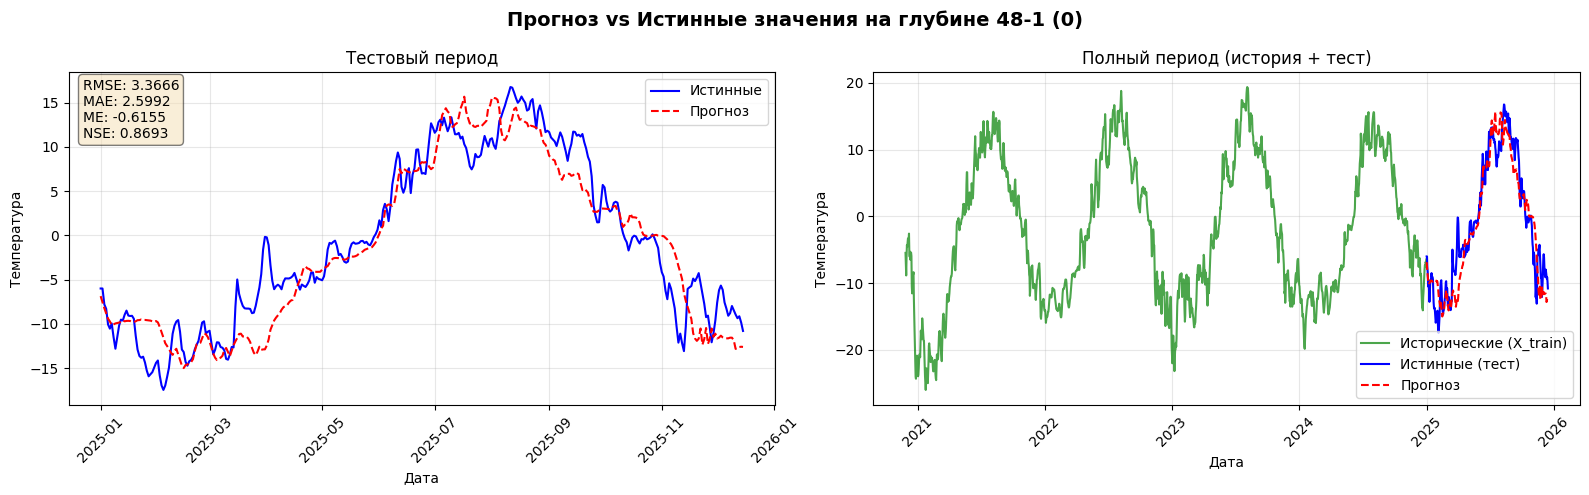

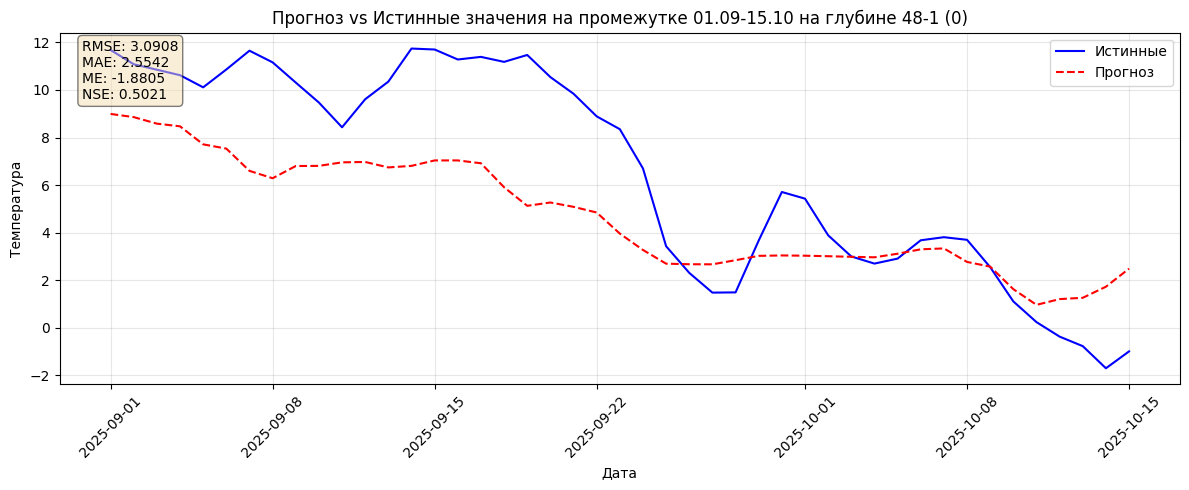

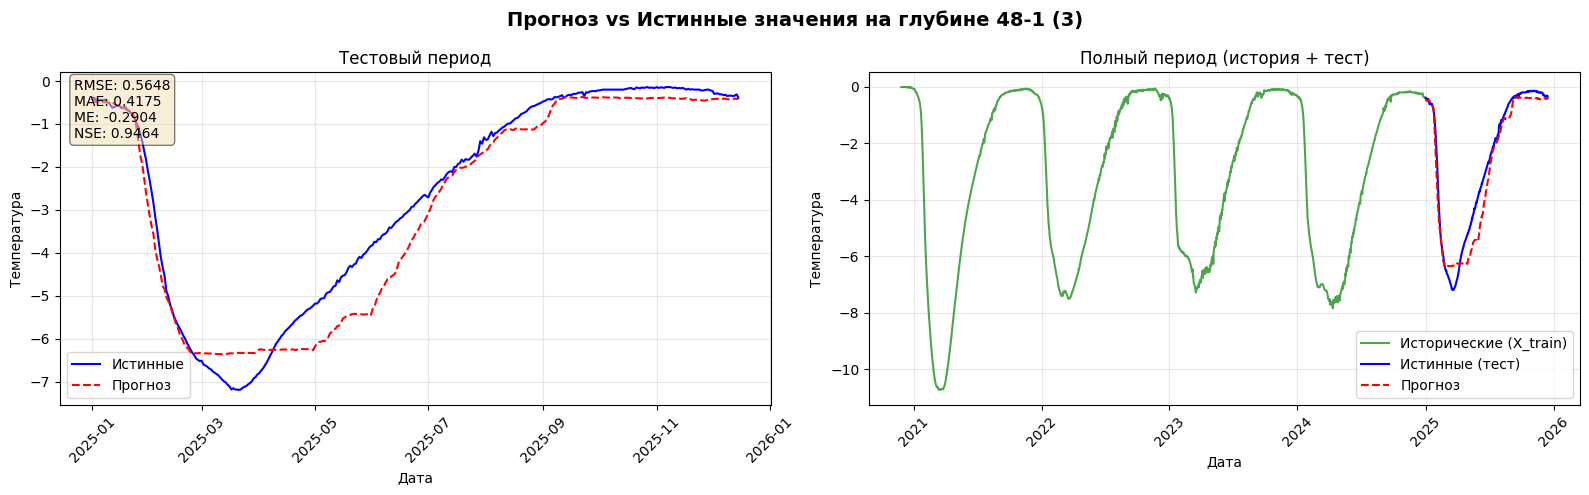

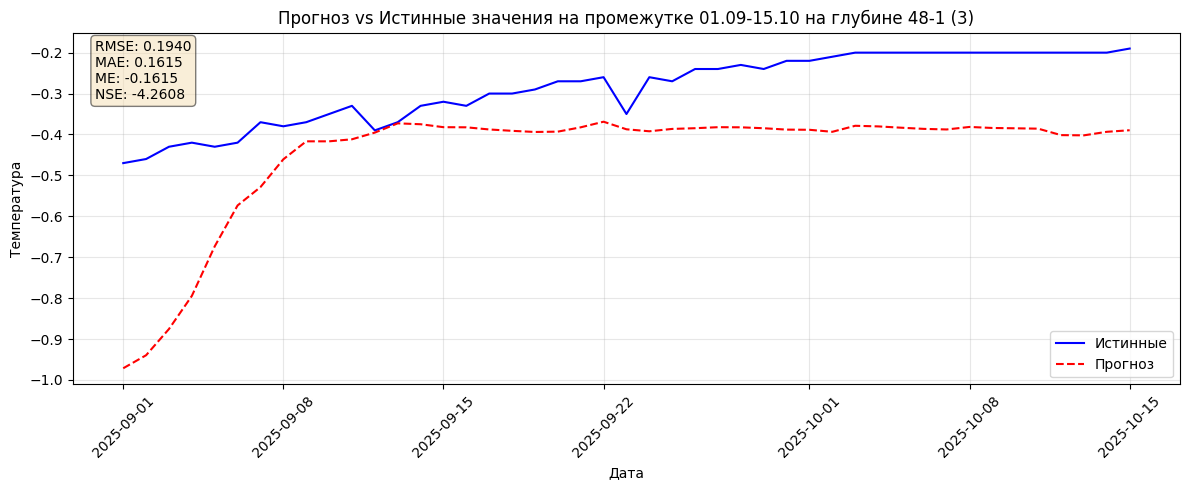

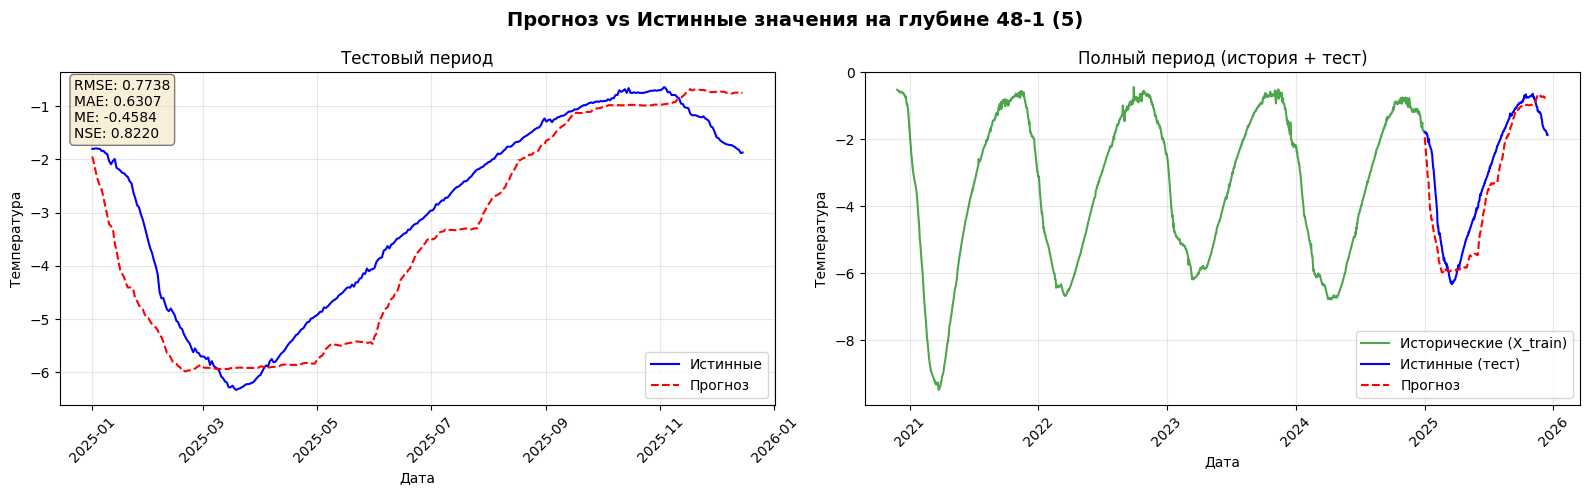

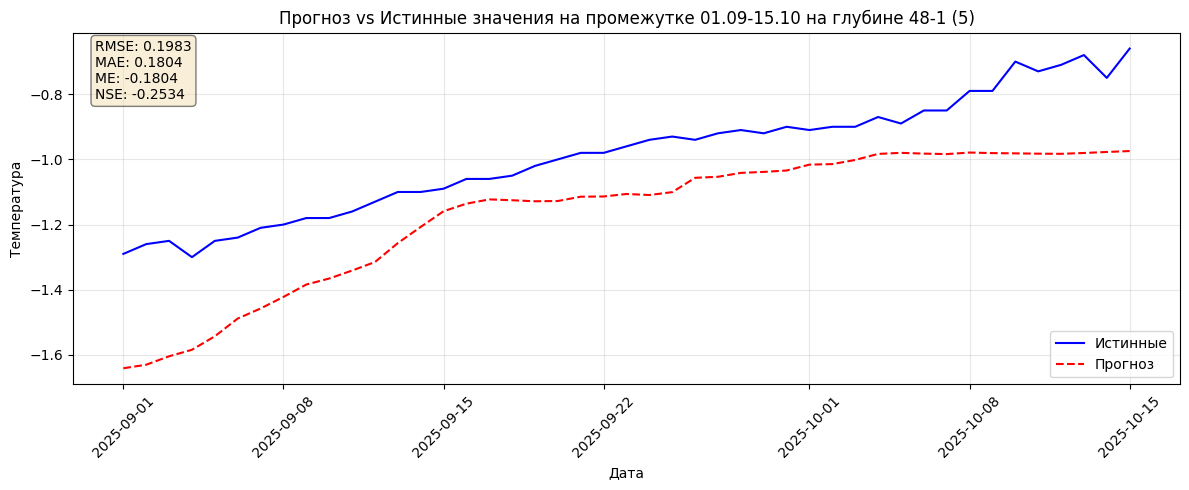

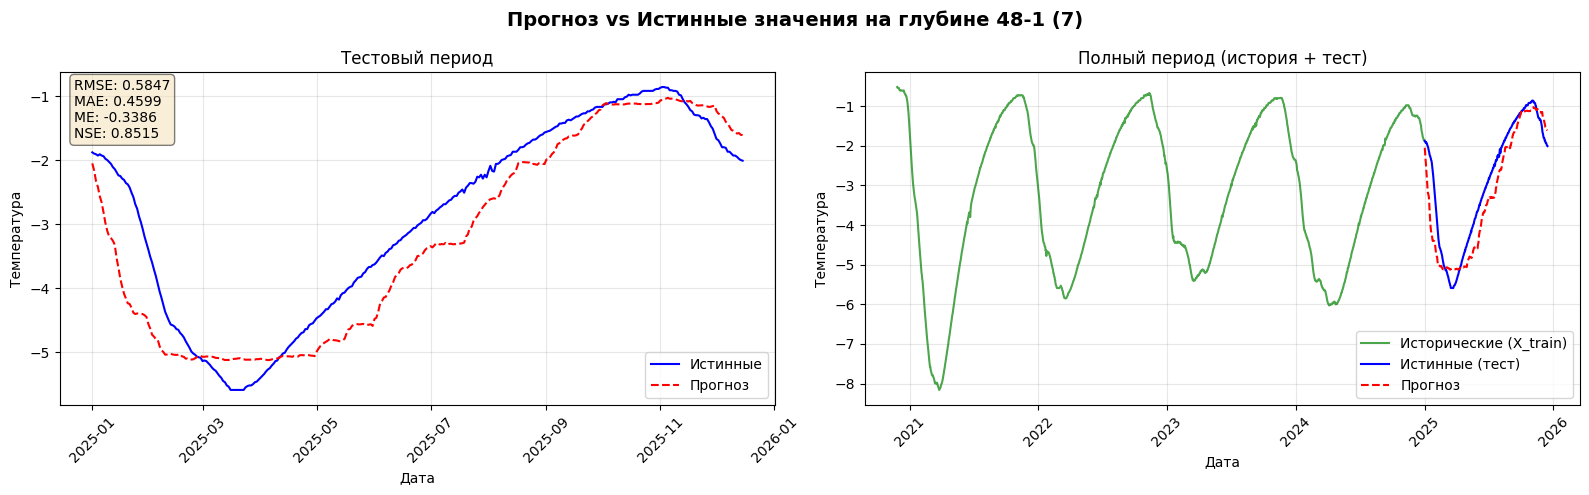

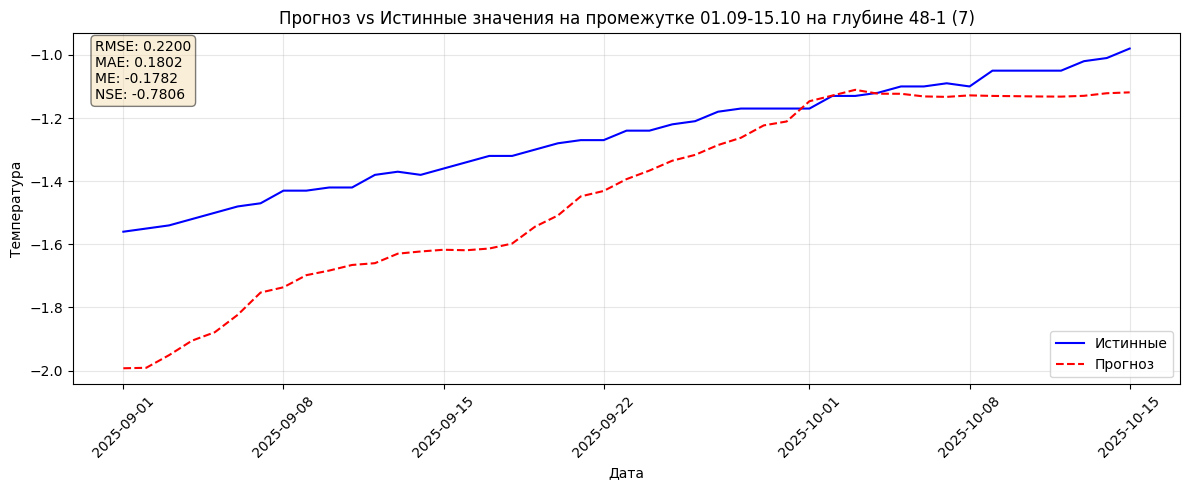

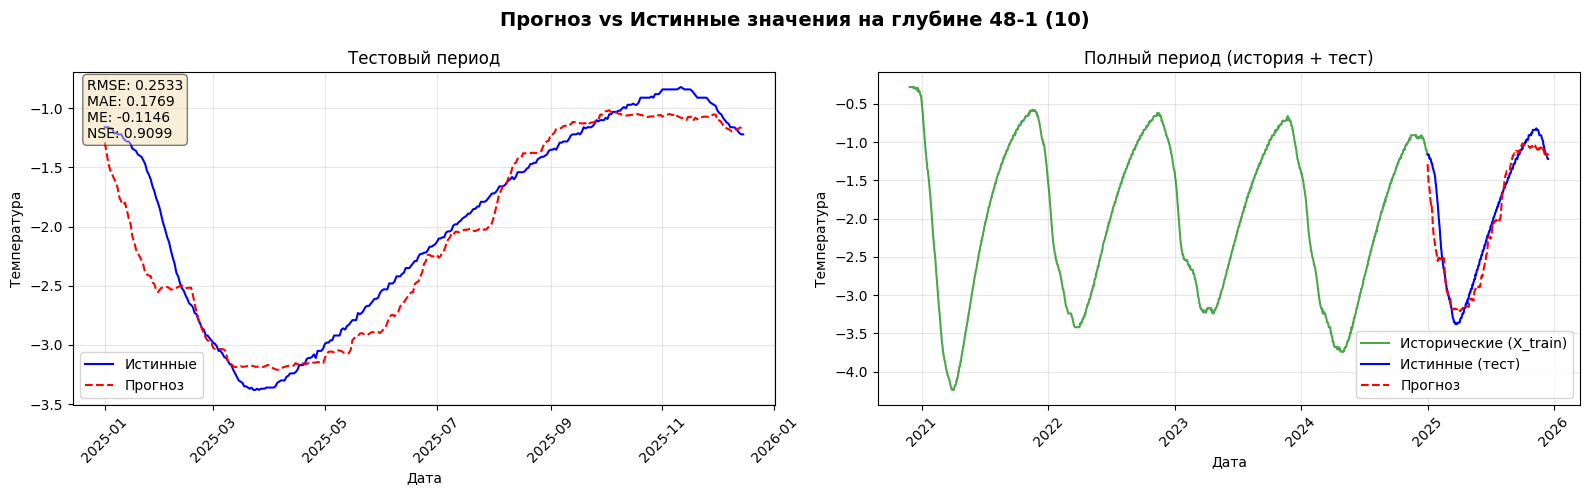

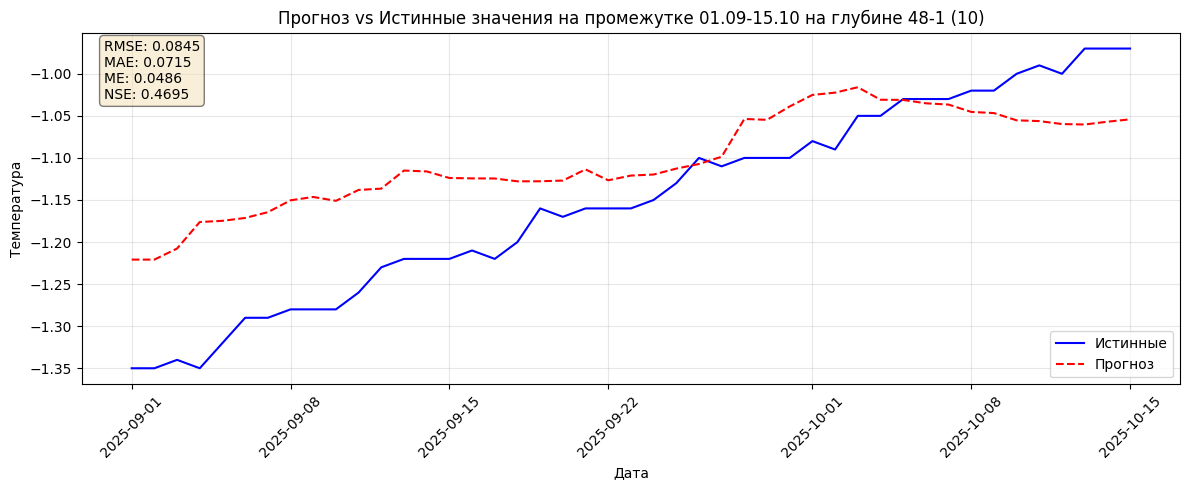

             feature  importance
0              lag_1   52.655853
1              lag_2   31.733350
5    day_of_year_sin    4.722703
3          Месяц_sin    4.066151
2  _level_skforecast    2.782883
6    day_of_year_cos    2.743791
4          Месяц_cos    1.295270


In [7]:
model = joblib.load(model_path)
predicts_long = model.predict(len(df_test), exog=df_test[exog_cols])
predicts = predicts_long.reset_index().pivot(index='index', columns='level', values='pred')
predicts.columns.name = None
for col in target_cols:
    y_pred = predicts[col]
    y_true = df_test[col]
    
    metrics = evaluate(y_true.values, y_pred.values)
    
    y_pred_autumn = y_pred['2025-09-01':'2025-10-15']
    metrics_autumn = evaluate(y_true['2025-09-01':'2025-10-15'].values, y_pred_autumn.values)
    
    plot_forecast_with_train(df_train_full[col], pd.DataFrame(y_true), pd.DataFrame(y_pred), metrics_dict=metrics, title=f'Прогноз vs Истинные значения на глубине {col}')
    plot_forecast(pd.DataFrame(y_true['2025-09-01':'2025-10-15']), pd.DataFrame(y_pred_autumn), metrics_dict=metrics_autumn, title=f'Прогноз vs Истинные значения на промежутке 01.09-15.10 на глубине {col}')
    
importances = model.get_feature_importances()
print(importances)